<a href="https://colab.research.google.com/github/Abhinav9895/Generative-AI-Internship/blob/main/Day8/StockPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime
import warnings

# Suppress warnings to keep the output clean
warnings.filterwarnings('ignore')

print("Step 1: Fetching latest market data...")

# We are testing with just 2 companies to keep it simple
tickers = ["AAPL", "MSFT"]

# Dynamically set dates
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = "2020-01-01"

# Download data for both tickers
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

print(f"Successfully downloaded data for {', '.join(tickers)}!")

# Display the last 5 days of closing prices to verify it worked
display(data['Close'].tail())

Step 1: Fetching latest market data...
Successfully downloaded data for AAPL, MSFT!


Ticker,AAPL,MSFT
Date,,
2026-06-10,291.579987,397.359985
2026-06-11,295.630005,390.339996
2026-06-12,291.130005,390.739990
2026-06-15,296.420013,399.760010
2026-06-16,299.239990,393.829987


Visualizing Raw Downloaded Data...



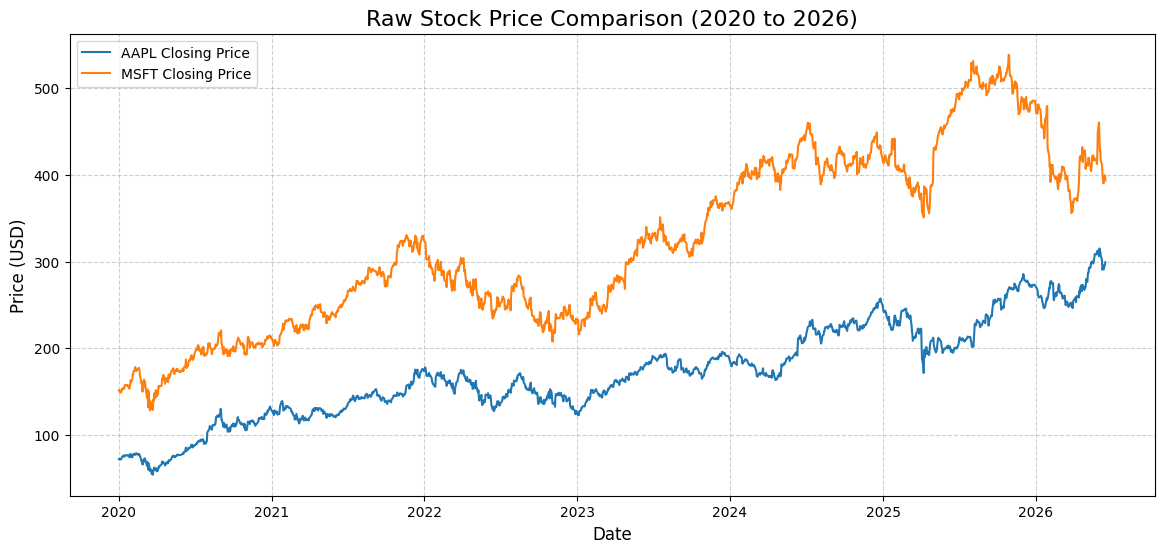

In [ ]:
import matplotlib.pyplot as plt

print("Visualizing Raw Downloaded Data...\n")

plt.figure(figsize=(14, 6))

# Loop through our downloaded tickers and plot their closing prices
for ticker in tickers:
    plt.plot(data.index, data['Close'][ticker], label=f"{ticker} Closing Price")

plt.title(f"Raw Stock Price Comparison ({start_date[:4]} to {end_date[:4]})", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:

print("Step 2: Engineering Features for Machine Learning...\n")

# Create an empty dictionary to hold the clean dataframes
processed_data = {}

for ticker in tickers:
    # Isolate the data for this specific company
    df = pd.DataFrame(data['Close'][ticker])
    df.columns = ['Close']

    # Calculate indicators (The clues for our AI)
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    df['Daily_Return'] = df['Close'].pct_change()

    # Target: 1 if tomorrow's price is higher than today's, else 0
    df['Target_Direction'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    # Drop rows with NaN values (the first 50 days won't have a 50-day average)
    df.dropna(inplace=True)

    # Save the processed data back into our dictionary
    processed_data[ticker] = df
    print(f"✅ Features engineered for {ticker}. Trading days available: {len(df)}")

# Display Apple's newly engineered features to verify
print("\nPreview of Apple's engineered data:")
display(processed_data['AAPL'].tail())

Step 2: Engineering Features for Machine Learning...

✅ Features engineered for AAPL. Trading days available: 1573
✅ Features engineered for MSFT. Trading days available: 1573

Preview of Apple's engineered data:


,Close,SMA_20,SMA_50,Daily_Return,Target_Direction
Date,,,,,
2026-06-10,291.579987,304.397000,283.805926,0.003545,1
2026-06-11,295.630005,304.235001,284.647399,0.013890,0
2026-06-12,291.130005,303.881001,285.362105,-0.015222,1
2026-06-15,296.420013,303.690501,286.176816,0.018171,1
2026-06-16,299.239990,303.760501,286.989182,0.009513,0



 📈 WALL STREET AI PREDICTION DASHBOARD 📉

Ticker: AAPL  | Test Accuracy:  49.8% | Tomorrow's Forecast: DOWN 🔴


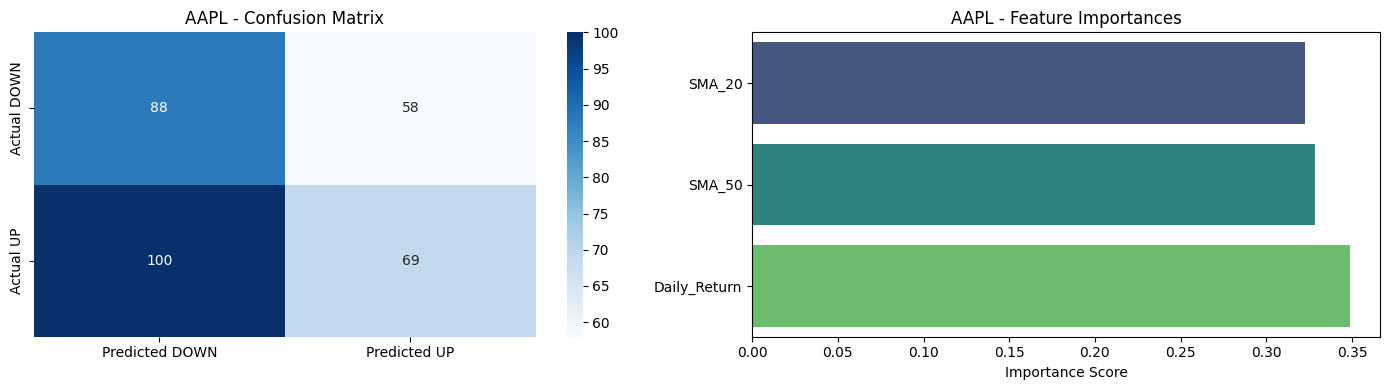

Ticker: MSFT  | Test Accuracy:  50.2% | Tomorrow's Forecast: UP   🟢


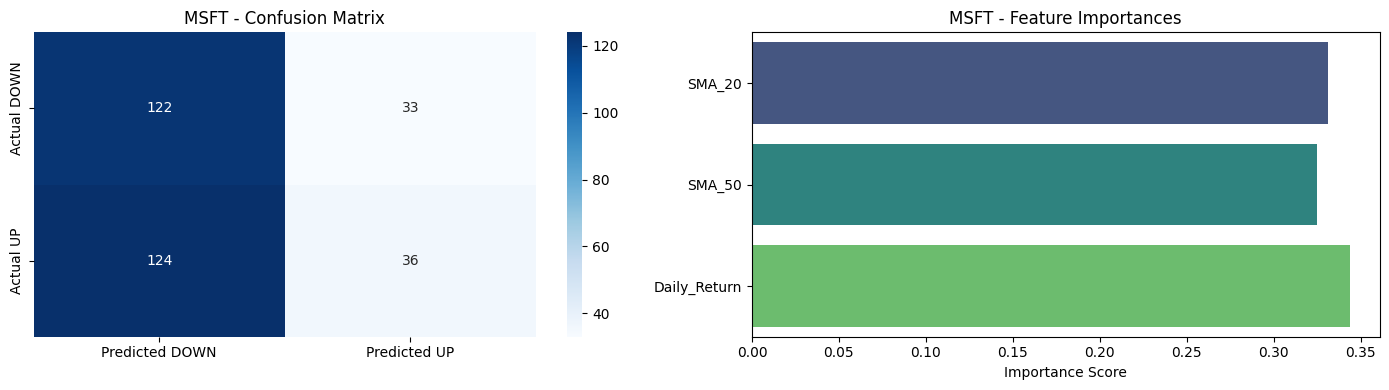

In [ ]:
# --- COLAB CELL 3: AI TRAINING & PREDICTION ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*50)
print(" 📈 WALL STREET AI PREDICTION DASHBOARD 📉")
print("="*50 + "\n")

# Loop through our dictionary of clean, processed stock data
for ticker in tickers:
    df = processed_data[ticker]

    # 1. Train/Test Chronological Split
    features = ['SMA_20', 'SMA_50', 'Daily_Return']
    X = df[features]
    y = df['Target_Direction']

    # Split: 80% for training, 20% for testing (no time traveling!)
    split_index = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    # 2. Train the Random Forest
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 3. Evaluate accuracy on the 20% test data
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    # 4. Predict Tomorrow's movement!
    latest_data = X.iloc[-1].values.reshape(1, -1)
    tomorrow_prediction = model.predict(latest_data)[0]

    trend = "UP   🟢" if tomorrow_prediction == 1 else "DOWN 🔴"

    # Print the clean dashboard results
    print(f"Ticker: {ticker:<5} | Test Accuracy: {accuracy*100:>5.1f}% | Tomorrow's Forecast: {trend}")

    # --- VISUALIZATION BLOCK ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Plot 1: Confusion Matrix
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Predicted DOWN', 'Predicted UP'],
                yticklabels=['Actual DOWN', 'Actual UP'])
    axes[0].set_title(f'{ticker} - Confusion Matrix')

    # Plot 2: Feature Importances (What the AI cares about most)
    importances = model.feature_importances_
    sns.barplot(x=importances, y=features, ax=axes[1], palette='viridis')
    axes[1].set_title(f'{ticker} - Feature Importances')
    axes[1].set_xlabel("Importance Score")

    plt.tight_layout()
    plt.show()

print("\n" + "="*50)

In [ ]:
# --- COLAB CELL 4: LSTM DATA PREPARATION ---
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("Step 4: Preparing Data for Deep Learning (LSTM)...\n")

# 1. Isolate the Raw Closing Prices for Apple
# We convert it to a 2D array because the scaler requires it
dataset = data['Close']['AAPL'].values.reshape(-1, 1)

# 2. Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

# 3. Create Sequences (The "Memory" Window)
# We will look at the past 60 days to predict the 61st day
window_size = 60
X_lstm, y_lstm = [], []

for i in range(window_size, len(scaled_data)):
    X_lstm.append(scaled_data[i-window_size:i, 0]) # The 60 days of history
    y_lstm.append(scaled_data[i, 0])               # The target price on day 61

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# 4. Reshape X into a 3D Tensor [samples, time steps, features]
# LSTMs strictly require 3D inputs to understand the flow of time
X_lstm = np.reshape(X_lstm, (X_lstm.shape[0], X_lstm.shape[1], 1))

# 5. Chronological Train-Test Split (80% Train, 20% Test)
split = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

print(f"✅ Data Sequenced!")
print(f"Training Shape: {X_train_lstm.shape} (Batches, 60-Day Windows, 1 Feature)")
print(f"Testing Shape:  {X_test_lstm.shape}")

Step 4: Preparing Data for Deep Learning (LSTM)...

✅ Data Sequenced!
Training Shape: (1249, 60, 1) (Batches, 60-Day Windows, 1 Feature)
Testing Shape:  (313, 60, 1)


Step 5: Building the LSTM Brain...

Training in progress... (This will take a minute!)
Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - loss: 0.0203 - val_loss: 0.0129
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0020 - val_loss: 0.0013
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0018 - val_loss: 0.0026
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0018 - val_loss: 0.0012
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0016 - val_loss: 0.0030
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0015 - val_loss: 0.0012
Epoch 9/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 10/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 133ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 11/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0

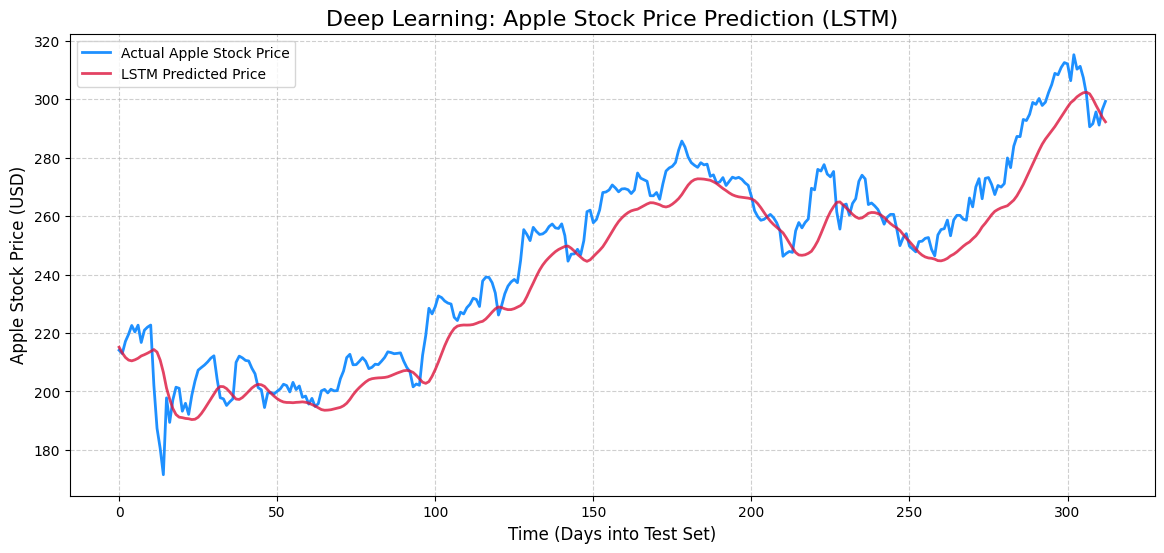

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

print("Step 5: Building the LSTM Brain...\n")

# 1. Initialize the Sequential Architecture
model_lstm = Sequential([
    # First LSTM Layer: Reads the 60-day window and passes the sequence forward
    LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2), # Drops 20% of neurons to prevent overfitting

    # Second LSTM Layer: Condenses the sequence into a final thought
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),

    # Dense Layers to output the final predicted price
    Dense(units=25),
    Dense(units=1)
])

# 2. Compile the model (Using Mean Squared Error to measure dollar distance)
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 3. Train the Model!
# We use epochs=20 so it passes over the data 20 times to learn the patterns.
print("Training in progress... (This will take a minute!)")
history = model_lstm.fit(X_train_lstm, y_train_lstm, batch_size=32, epochs=20,
                         validation_data=(X_test_lstm, y_test_lstm), verbose=1)

# 4. Make Predictions on the unseen Test Data
print("\nMaking predictions on the Test set...")
predictions_scaled = model_lstm.predict(X_test_lstm)

# 5. Inverse Transform (Convert the 0-1 decimals back into real Apple stock prices)
predictions_actual = scaler.inverse_transform(predictions_scaled)
y_test_actual = scaler.inverse_transform(y_test_lstm.reshape(-1, 1))

# 6. Visualize the AI's Predictions vs Reality
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, color='dodgerblue', label='Actual Apple Stock Price', linewidth=2)
plt.plot(predictions_actual, color='crimson', label='LSTM Predicted Price', linewidth=2, alpha=0.8)

plt.title('Deep Learning: Apple Stock Price Prediction (LSTM)', fontsize=16)
plt.xlabel('Time (Days into Test Set)', fontsize=12)
plt.ylabel('Apple Stock Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# --- COLAB CELL 6: PREDICTING TOMORROW ---
import numpy as np

print("\n" + "="*50)
print(" 🔮 PREDICTING TOMORROW'S OPENING TREND 🔮")
print("="*50)

# 1. Grab the absolute latest 60 days of our scaled data (using the original variable 'scaled_data')
latest_60_days = scaled_data[-window_size:]

# 2. Reshape it to be a 3D Tensor: (1 sample, 60 days, 1 feature)
latest_60_days_reshaped = latest_60_days.reshape(1, window_size, 1)

# 3. Predict the next day's scaled price
tomorrow_predicted_scaled = model_lstm.predict(latest_60_days_reshaped, verbose=0)

# 4. Inverse transform back to real USD using the original 'scaler'
tomorrow_price_usd = scaler.inverse_transform(tomorrow_predicted_scaled)[0][0]

# 5. Get today's actual close price for comparison
today_actual_price = dataset[-1, 0]

print(f"\nToday's Actual Closing Price: ${today_actual_price:.2f}")
print(f"AI Predicted Price for Tomorrow: ${tomorrow_price_usd:.2f}")

if tomorrow_price_usd > today_actual_price:
    print("📈 Model Forecast: Apple is trending UP tomorrow.")
else:
    print("📉 Model Forecast: Apple is trending DOWN tomorrow.")
print("="*50)


 🔮 PREDICTING TOMORROW'S OPENING TREND 🔮

Today's Actual Closing Price: $299.24
AI Predicted Price for Tomorrow: $291.28
📉 Model Forecast: Apple is trending DOWN tomorrow.


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("Step 4 (Multi): Preparing Multivariate Data...\n")

# 1. Grab 4 features instead of 1
features_to_use = ['Close', 'SMA_20', 'SMA_50', 'Daily_Return']
df_multi = processed_data['AAPL'][features_to_use].copy()
dataset_multi = df_multi.values

# 2. Create dedicated scalers for the Multivariate model
target_scaler_multi = MinMaxScaler(feature_range=(0, 1))
scaled_target_multi = target_scaler_multi.fit_transform(dataset_multi[:, 0].reshape(-1, 1))

feature_scaler_multi = MinMaxScaler(feature_range=(0, 1))
scaled_features_multi = feature_scaler_multi.fit_transform(dataset_multi)

# 3. Create Sequences
window_size = 60
X_multi, y_multi = [], []

for i in range(window_size, len(scaled_features_multi)):
    X_multi.append(scaled_features_multi[i-window_size:i, :])
    y_multi.append(scaled_target_multi[i, 0])

X_multi, y_multi = np.array(X_multi), np.array(y_multi)

# 4. Split: 80% Train, 20% Test
split_multi = int(len(X_multi) * 0.8)
X_train_multi, X_test_multi = X_multi[:split_multi], X_multi[split_multi:]
y_train_multi, y_test_multi = y_multi[:split_multi], y_multi[split_multi:]

print(f"✅ Multivariate Data Sequenced!")
print(f"Training Shape: {X_train_multi.shape} (Batches, 60-Day Windows, {len(features_to_use)} Features)")

Step 4 (Multi): Preparing Multivariate Data...

✅ Multivariate Data Sequenced!
Training Shape: (1210, 60, 4) (Batches, 60-Day Windows, 4 Features)


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

print("Step 4 (Multi): Preparing Multivariate Data...\n")

# 1. Grab 4 features instead of 1
features_to_use = ['Close', 'SMA_20', 'SMA_50', 'Daily_Return']
df_multi = processed_data['AAPL'][features_to_use].copy()
dataset_multi = df_multi.values

# 2. Create dedicated scalers for the Multivariate model
target_scaler_multi = MinMaxScaler(feature_range=(0, 1))
scaled_target_multi = target_scaler_multi.fit_transform(dataset_multi[:, 0].reshape(-1, 1))

feature_scaler_multi = MinMaxScaler(feature_range=(0, 1))
scaled_features_multi = feature_scaler_multi.fit_transform(dataset_multi)

# 3. Create Sequences
window_size = 60
X_multi, y_multi = [], []

for i in range(window_size, len(scaled_features_multi)):
    X_multi.append(scaled_features_multi[i-window_size:i, :])
    y_multi.append(scaled_target_multi[i, 0])

X_multi, y_multi = np.array(X_multi), np.array(y_multi)

# 4. Split: 80% Train, 20% Test
split_multi = int(len(X_multi) * 0.8)
X_train_multi, X_test_multi = X_multi[:split_multi], X_multi[split_multi:]
y_train_multi, y_test_multi = y_multi[:split_multi], y_multi[split_multi:]

print(f"✅ Multivariate Data Sequenced!")
print(f"Training Shape: {X_train_multi.shape} (Batches, 60-Day Windows, {len(features_to_use)} Features)")

Step 4 (Multi): Preparing Multivariate Data...

✅ Multivariate Data Sequenced!
Training Shape: (1210, 60, 4) (Batches, 60-Day Windows, 4 Features)


Step 5 (Multi): Building the Multivariate LSTM Brain...

Training in progress... (This will take a minute!)
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - loss: 0.0127 - val_loss: 0.0040
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0036 - val_loss: 0.0065
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0031 - val_loss: 0.0043
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0029 - val_loss: 0.0090
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0028 - val_loss: 0.0025
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0015 - val_loss: 0.0016
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0015 - val_loss: 0.0042
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s

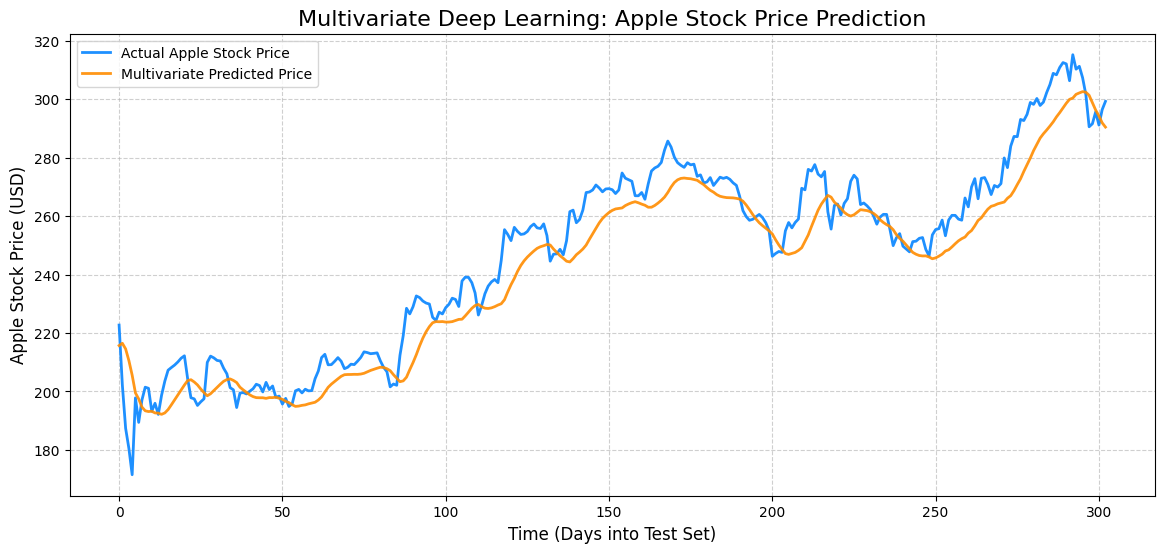

In [ ]:
# --- COLAB CELL 8: TRAINING THE MULTIVARIATE LSTM ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

print("Step 5 (Multi): Building the Multivariate LSTM Brain...\n")

# 1. Initialize a brand new model
model_multi = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train_multi.shape[1], X_train_multi.shape[2])),
    Dropout(0.2),

    LSTM(units=50, return_sequences=False),
    Dropout(0.2),

    Dense(units=25),
    Dense(units=1)
])

# 2. Compile and Train
model_multi.compile(optimizer='adam', loss='mean_squared_error')
print("Training in progress... (This will take a minute!)")
history_multi = model_multi.fit(X_train_multi, y_train_multi, batch_size=32, epochs=20,
                                validation_data=(X_test_multi, y_test_multi), verbose=1)

# 3. Predict and Inverse Transform
print("\nMaking predictions on the Test set...")
predictions_scaled_multi = model_multi.predict(X_test_multi)
predictions_actual_multi = target_scaler_multi.inverse_transform(predictions_scaled_multi)
y_test_actual_multi = target_scaler_multi.inverse_transform(y_test_multi.reshape(-1, 1))

# 4. Visualize (Using an Orange line so you know it's the new model!)
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual_multi, color='dodgerblue', label='Actual Apple Stock Price', linewidth=2)
plt.plot(predictions_actual_multi, color='darkorange', label='Multivariate Predicted Price', linewidth=2, alpha=0.9)
plt.title('Multivariate Deep Learning: Apple Stock Price Prediction', fontsize=16)
plt.xlabel('Time (Days into Test Set)', fontsize=12)
plt.ylabel('Apple Stock Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# --- COLAB CELL 9: PREDICTING TOMORROW (MULTIVARIATE) ---
import numpy as np

print("\n" + "="*50)
print(" 🔮 PREDICTING TOMORROW'S OPENING TREND (MULTIVARIATE) 🔮")
print("="*50)

# 1. Grab the latest 60 days using the new multi feature scaler
latest_60_days_multi = scaled_features_multi[-window_size:]

# 2. Reshape to 3D Tensor
latest_60_days_reshaped_multi = latest_60_days_multi.reshape(1, window_size, X_train_multi.shape[2])

# 3. Predict with the new model
tomorrow_predicted_scaled_multi = model_multi.predict(latest_60_days_reshaped_multi, verbose=0)

# 4. Inverse transform back to real USD
tomorrow_price_usd_multi = target_scaler_multi.inverse_transform(tomorrow_predicted_scaled_multi)[0][0]

# 5. Get today's actual close price
today_actual_price_multi = dataset_multi[-1, 0]

print(f"\nToday's Actual Closing Price: ${today_actual_price_multi:.2f}")
print(f"AI Predicted Price for Tomorrow: ${tomorrow_price_usd_multi:.2f}")

if tomorrow_price_usd_multi > today_actual_price_multi:
    print("📈 Multivariate Forecast: Apple is trending UP tomorrow.")
else:
    print("📉 Multivariate Forecast: Apple is trending DOWN tomorrow.")
print("="*50)


 🔮 PREDICTING TOMORROW'S OPENING TREND (MULTIVARIATE) 🔮

Today's Actual Closing Price: $299.24
AI Predicted Price for Tomorrow: $289.63
📉 Multivariate Forecast: Apple is trending DOWN tomorrow.
